In [1]:
from openmm.app import *
from openmm import *
from openmm.unit import *
from sys import stdout
from openmmtools.integrators import LangevinIntegrator, LangevinSplittingGirsanov
from openmmplumed import PlumedForce
import matplotlib

from deeptime.decomposition import TICA

import numpy as np
import MDAnalysis as md
from matplotlib import pyplot as plt

from deeptime.clustering import MiniBatchKMeans
from deeptime.markov import TransitionCountEstimator
from deeptime.markov.msm import MaximumLikelihoodMSM
from deeptime.plots import plot_implied_timescales
from deeptime.util.validation import implied_timescales
from deeptime.markov import GirsanovReweightingEstimator

from scipy.linalg import eig
from scipy.stats import gaussian_kde

from pymbar import MBAR
import plumed
import subprocess

from scipy.interpolate import CubicSpline

import gc

import warnings
warnings.filterwarnings("ignore")

matplotlib.rcParams['font.size'] = 20

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

****** PyMBAR will use 64-bit JAX! *******
* JAX is currently set to 32-bit bitsize *
* which is its default.                  *
*                                        *
* PyMBAR requires 64-bit mode and WILL   *
* enable JAX's 64-bit mode when called.  *
*                                        *
* This MAY cause problems with other     *
* Uses of JAX in the same code.          *
******************************************

/home/mingyuan/miniconda3/envs/girsanov-torch/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readt

In [2]:
def build_MSM(msm_lagtime,assignments):
    counts = TransitionCountEstimator(lagtime=msm_lagtime, count_mode='sliding').fit_fetch(assignments)
    msm = MaximumLikelihoodMSM().fit_fetch(counts)
    return msm

def Girsanov_MSM(msm_lagtime,assignments,reweighting_factors,stationary_pi=None):
    count_estimator = GirsanovReweightingEstimator(lagtime=msm_lagtime,count_mode='sliding')
    counts = count_estimator.fit(data=assignments,reweighting_factors=reweighting_factors).fetch_model()
    if stationary_pi is not None:
        msm = MaximumLikelihoodMSM(stationary_distribution_constraint=stationary_pi).fit_fetch(counts)
    else:
        msm = MaximumLikelihoodMSM().fit_fetch(counts)
    return msm

# We need to further modify assignments_unbiased and assignments_biased
def reorganize_indices(assignments,n_microstates):
    populated_states = np.unique(assignments)
    empty_states = []
    assignments_new = np.zeros(assignments.shape,dtype=np.int32)
    shift = 0
    for idx in range(n_microstates):
        if idx in populated_states:
            idx_new = idx - shift
            assignments_new[np.where(assignments == idx)] = idx_new
        else:
            empty_states.append(idx)
            shift += 1
    return assignments_new, empty_states

def reorganize_eigenvectors(msm,n_eigenvectors,n_microstates,empty_states,align=None):
    eigenvectors_new = np.zeros((n_microstates,n_eigenvectors))
    shift = 0
    for idx in range(n_microstates):
        if idx in empty_states:
            shift += 1
            empty_entries = np.zeros(n_eigenvectors,)
            # Let values of eigenvectors being nan for plotting
            empty_entries[:] = np.nan
            eigenvectors_new[idx,:] = empty_entries
        else:
            idx_new = idx - shift
            pi_idx = msm.stationary_distribution[idx_new]
            ev_idx = msm.eigenvectors_right()[idx_new,1:n_eigenvectors]
            eigenvectors_new[idx,:] = np.concatenate([[pi_idx],ev_idx])
    if align is not None:
        # Align each eigenvector with the reference eigenvector
        for i in range(1,n_eigenvectors):
            if np.nansum(np.abs(-eigenvectors_new[:,i] - align[:,i])) < np.nansum(np.abs(eigenvectors_new[:,i] - align[:,i])):
                eigenvectors_new[:,i] = -eigenvectors_new[:,i]
    return eigenvectors_new

In [3]:
data_ref = plumed.read_as_pandas('COLVAR/ala2/COLVAR_ref').to_numpy()[:,1:]
# Read data
data_phi = plumed.read_as_pandas('COLVAR/ala2/COLVAR_phi').to_numpy()[:500000,1:]
data_psi = plumed.read_as_pandas('COLVAR/ala2/COLVAR_psi').to_numpy()[:,1:]
# Read weights
M_phi = np.load('traj_and_dat/ala2/M_phi_build_up.npy')[:500000]
M_psi = np.load('traj_and_dat/ala2/M_psi_build_up.npy')
# Read Bias
phi_bias = np.load('traj_and_dat/ala2/Bias_phi_build_up.npy')
psi_bias = np.load('traj_and_dat/ala2/Bias_psi_build_up.npy')
# Concat data
phi_concat = np.concatenate([data_phi[:,0],data_psi[:,0]])
psi_concat = np.concatenate([data_phi[:,1],data_psi[:,1]])
data = np.vstack([phi_concat,psi_concat]).T
M = np.vstack([M_phi,M_psi])
reweighting_factors = (np.ones(M.shape),M)

In [4]:
# MBAR
temp = 310
kt = 8.314 * temp / 1000
phi_concat = np.concatenate([data_phi[:,0],data_psi[:,0]])
psi_concat = np.concatenate([data_phi[:,1],data_psi[:,1]])
u_kn = np.zeros((3,phi_concat.shape[0]))
# Phi bias
phi_grid = np.linspace(-np.pi,np.pi,100)
phi_spline = CubicSpline(phi_grid,phi_bias,bc_type='periodic')
u_kn[1] = phi_spline(phi_concat) / kt
# Psi bias
psi_grid = np.linspace(-np.pi,np.pi,100)
psi_spline = CubicSpline(psi_grid,psi_bias,bc_type='periodic')
u_kn[2] = psi_spline(psi_concat) / kt
N_k = np.ones(3,) * data_phi.shape[0]
N_k[0] = 0
mbar = MBAR(u_kn, N_k)
sample_weights = mbar.W_nk[:,0]


******* JAX 64-bit mode is now on! *******
*     JAX is now set to 64-bit mode!     *
*   This MAY cause problems with other   *
*      uses of JAX in the same code.     *
******************************************

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [5]:
# Grid Discretization
from deeptime.clustering import BoxDiscretization

# Construct grid box
dim = 2
n_boxes = 50                         # hence 50x50=2500 grid boxes
v0 = np.array([-np.pi,-np.pi])
v1 = np.array([np.pi,np.pi])

grid_box = BoxDiscretization(
    dim=dim,  # the number of dimensions the data lives in
    n_boxes=n_boxes,  # number of boxes per axis (can also be single int for all axes)
    v0=v0,
    v1=v1
)

n_microstates = n_boxes**dim
microstates = grid_box.fit(data_ref).fetch_model()
# Unbiased Reference
assignments_ref = microstates.transform(data_ref).reshape(-1,)
assignments_ref,empty_states_ref = reorganize_indices(assignments_ref,n_microstates)
# biased clusters
assignments = microstates.transform(data).reshape(2,-1)
assignments, empty_states = reorganize_indices(assignments,n_microstates)
# Histogram over clusters
histogram = np.bincount(assignments.reshape(-1,),weights=sample_weights)
stationary_pi = histogram / np.sum(histogram)

In [6]:
n_eigenvectors = 4               # Number of eigenvectors to compute, including the stationary vector

In [7]:
# Evaluate Implied Timescales
n_processes = n_eigenvectors        # Display one extra trivial process
its_lagtimes = np.array(np.linspace(1,10,10),dtype=np.int32)
its_lagtimes_ref = np.array(np.linspace(1,10,10),dtype=np.int32)

# reference ITS
models = []
for its_lagtime in its_lagtimes_ref:
    counts = TransitionCountEstimator(lagtime=its_lagtime, count_mode='sliding').fit_fetch(assignments_ref)
    models.append(MaximumLikelihoodMSM().fit_fetch(counts))
its_data_ref = implied_timescales(models)

# pi-Girsanov ITS
models = []
for its_lagtime in its_lagtimes:
    count_estimator = GirsanovReweightingEstimator(lagtime=its_lagtime,count_mode='sliding')
    counts = count_estimator.fit(data=assignments,reweighting_factors=reweighting_factors).fetch_model()
    models.append(MaximumLikelihoodMSM(stationary_distribution_constraint=stationary_pi).fit_fetch(counts))
its_data = implied_timescales(models)

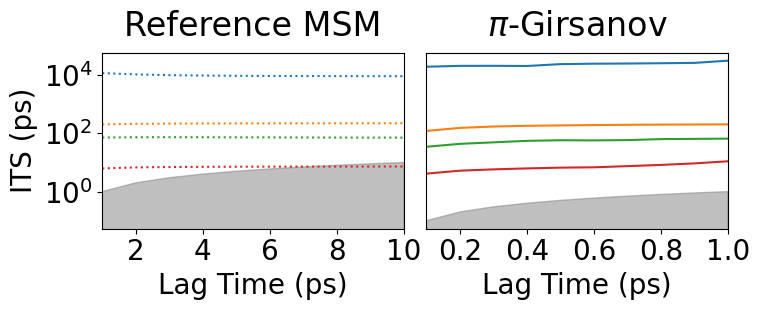

In [14]:
s = 15
ms = 5
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Convert unit into picosecond
per_step_ref = 1
per_step = 0.1

fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(8,3.5))

# Reference
for n in range(n_processes):
    ax[0].plot(its_lagtimes_ref*per_step_ref,its_data_ref.timescales_for_process(n)*per_step_ref,color=colors[n],linestyle=':')
    ax[1].plot(its_lagtimes*per_step,its_data.timescales_for_process(n)*per_step,color=colors[n])
    
ax[0].set_yscale('log')
ax[1].set_yscale('log')   
ax[0].set_xlabel('Lag Time (ps)')
ax[1].set_xlabel('Lag Time (ps)')
ax[1].yaxis.set_visible(False)
ax[0].fill_between(its_lagtimes, np.full((len(its_lagtimes),),fill_value=0), its_lagtimes, alpha=0.5, color='grey')
ax[1].fill_between(its_lagtimes*per_step, np.full((len(its_lagtimes),),fill_value=0), its_lagtimes*per_step, alpha=0.5, color='grey')
ax[0].set_ylim(ax[1].get_ylim())
ax[0].set_xlim((1,10))
ax[1].set_xlim((0.1,1))
ax[0].set_xticks([2,4,6,8,10])
ax[1].set_xticks([0.2,0.4,0.6,0.8,1])
ax[0].set_ylabel('ITS (ps)')
ax[0].set_title('Reference MSM',pad=12)
ax[1].set_title('$\pi$-Girsanov',pad=12)

plt.tight_layout()
plt.subplots_adjust(wspace=0.075)
plt.savefig('figures/ala2/its.png',dpi=600)
plt.show()

In [9]:
# Build reference MSM
msm_lagtime = 1
msm_ref = build_MSM(msm_lagtime,assignments_ref)
eigenvectors_ref = reorganize_eigenvectors(msm_ref,n_eigenvectors,n_microstates,empty_states_ref)

# Build pi-Girsanov MSM
msm_lagtime = 10
msm = Girsanov_MSM(msm_lagtime,assignments,reweighting_factors,stationary_pi=stationary_pi)
ev = reorganize_eigenvectors(msm,n_eigenvectors,n_microstates,empty_states)

vmin = []
vmax = []
for i in range(n_eigenvectors):
    vmin.append(np.nanmin([np.nanmin(eigenvectors_ref[:,i]), np.nanmin(ev[:,i])]))
    vmax.append(np.nanmax([np.nanmax(eigenvectors_ref[:,i]), np.nanmax(ev[:,i])]))

eigenvectors_ref = eigenvectors_ref.reshape(n_boxes,n_boxes,-1)
ev = ev.reshape(n_boxes,n_boxes,-1)

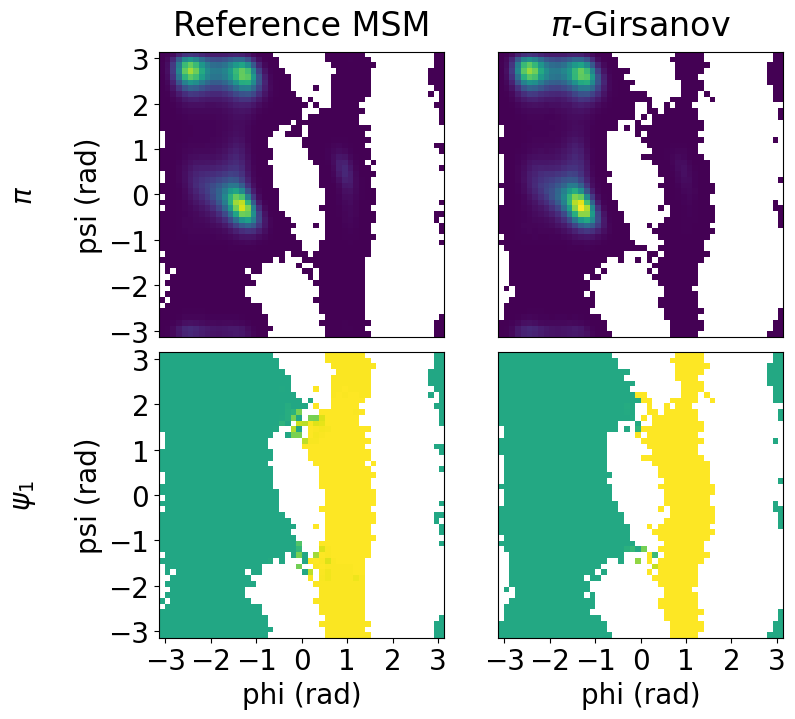

In [10]:
cmap = 'viridis'
origin = 'lower'
extent = [-np.pi, np.pi, -np.pi, np.pi]
ticks = [-3,-2,-1,0,1,2,3]

fig,ax = plt.subplots(nrows=2,ncols=2,figsize=(8,7),constrained_layout=True)
plt.setp(ax, 
         xticks=ticks, yticks=ticks,)

for i in range(2):
    sc = ax[i,0].imshow(eigenvectors_ref[:,:,i],cmap=cmap,origin=origin,extent=extent,vmin=vmin[i],vmax=vmax[i])
    if i == 1:   # revert eigenvectors sign to align them
        ax[i,1].imshow(-ev[:,:,i],cmap=cmap,origin=origin,extent=extent,vmin=vmin[i],vmax=vmax[i])
    else:
        ax[i,1].imshow(ev[:,:,i],cmap=cmap,origin=origin,extent=extent,vmin=vmin[i],vmax=vmax[i])
    ax[i,1].tick_params(left=False, labelleft=False)
    ax[i,0].set_xlim(-np.pi,np.pi)
    ax[i,0].set_ylim(-np.pi,np.pi)
    ax[i,1].set_xlim(-np.pi,np.pi)
    ax[i,1].set_ylim(-np.pi,np.pi)
    if i == 0:
        ax[i,0].set_ylabel('$\pi$\n\npsi (rad)')
    else:
        ax[i,0].set_ylabel('$\psi_{i}$\n\npsi (rad)'.format(i=i))
    if i != 1:
        ax[i,0].tick_params(bottom=False, labelbottom=False)
        ax[i,1].tick_params(bottom=False, labelbottom=False)
    else:
        ax[i,0].set_xlabel('phi (rad)')
        ax[i,1].set_xlabel('phi (rad)')
        
ax[0,0].set_title('Reference MSM',pad=12)
ax[0,1].set_title('$\pi$-Girsanov',pad=12)
fig.set_constrained_layout_pads(w_pad=0.0, h_pad=0.0, wspace=0.0, hspace=0.0)
plt.savefig('figures/ala2/ev.png',dpi=600)
plt.show()

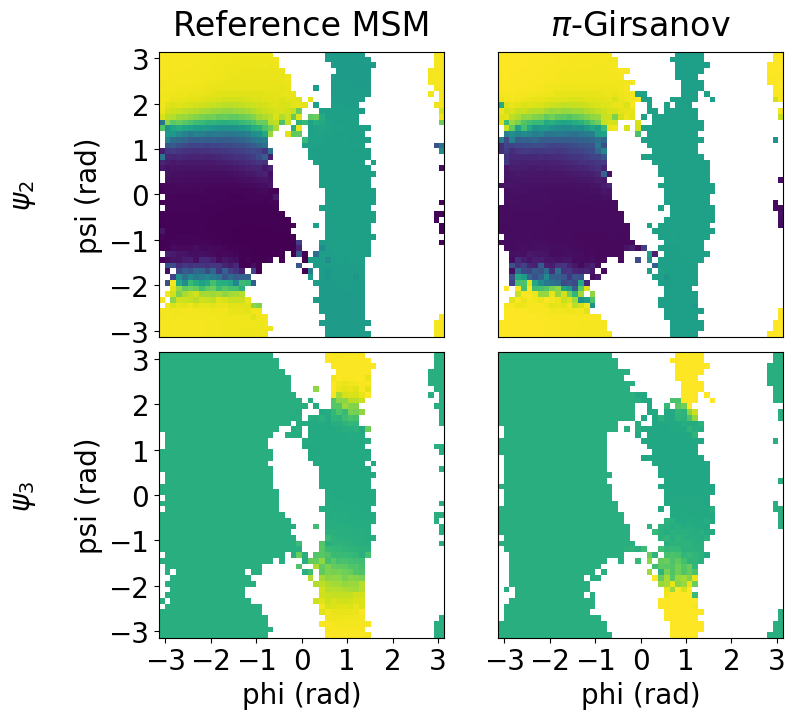

In [12]:
cmap = 'viridis'
origin = 'lower'
extent = [-np.pi, np.pi, -np.pi, np.pi]
ticks = [-3,-2,-1,0,1,2,3]

fig,ax = plt.subplots(nrows=2,ncols=2,figsize=(8,7),constrained_layout=True)
plt.setp(ax, 
         xticks=ticks, yticks=ticks,)

for i in range(2):
    sc = ax[i,0].imshow(eigenvectors_ref[:,:,i+2],cmap=cmap,origin=origin,extent=extent,vmin=vmin[i+2],vmax=vmax[i+2])
    if i == 1:   # revert eigenvectors sign to align them
        ax[i,1].imshow(-ev[:,:,i+2],cmap=cmap,origin=origin,extent=extent,vmin=vmin[i+2],vmax=vmax[i+2])
    else:
        ax[i,1].imshow(ev[:,:,i+2],cmap=cmap,origin=origin,extent=extent,vmin=vmin[i+2],vmax=vmax[i+2])
    ax[i,1].tick_params(left=False, labelleft=False)
    ax[i,0].set_xlim(-np.pi,np.pi)
    ax[i,0].set_ylim(-np.pi,np.pi)
    ax[i,1].set_xlim(-np.pi,np.pi)
    ax[i,1].set_ylim(-np.pi,np.pi)
    if i == 0:
        ax[i,0].set_ylabel('$\psi_2$\n\npsi (rad)')
    else:
        ax[i,0].set_ylabel('$\psi_3$\n\npsi (rad)')
    if i != 1:
        ax[i,0].tick_params(bottom=False, labelbottom=False)
        ax[i,1].tick_params(bottom=False, labelbottom=False)
    else:
        ax[i,0].set_xlabel('phi (rad)')
        ax[i,1].set_xlabel('phi (rad)')
        
ax[0,0].set_title('Reference MSM',pad=12)
ax[0,1].set_title('$\pi$-Girsanov',pad=12)
fig.set_constrained_layout_pads(w_pad=0.0, h_pad=0.0, wspace=0.0, hspace=0.0)
plt.savefig('figures/ala2/ev2.png',dpi=600)
plt.show()